# 06 — Hybrid Fraud Detection: XGBoost + Anomaly Signal (v2: full feature set)

Controlled A/B test of the hybrid hypothesis on the full encoded feature set:

- **Model A (base):** XGBoost on `feature_list.json` (identical to notebook 04)
- **Model B (hybrid):** same features **+ `anomaly_score`** from notebook 05
- Same time-based 70/10/20 split, same hyperparameters, same future test window — Δ PR-AUC isolates the anomaly signal's true contribution

Also: evaluated three-tier decision engine, investigation-queue export with identifiers, SHAP explanations saved as PNGs.

In [1]:
# CELL 1 - Load hybrid dataset, sort chronologically
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve)

df = pd.read_csv("../data/processed/fraud_features_with_anomaly_iforest.csv")
df["TransactionDT"] = pd.to_datetime(df["TransactionDT"])
df = df.sort_values("TransactionDT").reset_index(drop=True)

os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)
print(f"Loaded: {df.shape}")

Loaded: (590540, 85)


In [2]:
# CELL 2 - Feature sets: the ONLY difference is anomaly_score
# base list comes from the SAME canonical file notebook 04 reads,
# so the A/B comparison is controlled by construction.
base_features = json.load(open("../data/processed/feature_list.json"))
hybrid_features = base_features + ["anomaly_score"]

missing = [f for f in hybrid_features if f not in df.columns]
assert not missing, f"Missing columns: {missing} - re-run notebooks 01-05 first"
print(f"base: {len(base_features)} features | hybrid: {len(hybrid_features)}")

base: 74 features | hybrid: 75


In [3]:
# CELL 3 - Time-based split, IDENTICAL to notebook 04
n = len(df)
train_end, val_end = int(n * 0.70), int(n * 0.80)

train_idx = df.index[:train_end]
val_idx   = df.index[train_end:val_end]
test_idx  = df.index[val_end:]

y = df["isFraud"]
y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]
print(f"train {len(train_idx):,} | val {len(val_idx):,} | test {len(test_idx):,} (future)")

train 413,378 | val 59,054 | test 118,108 (future)


In [4]:
# CELL 4 - Train BOTH models: same split, same hyperparameters
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def train_xgb(feature_list):
    m = xgb.XGBClassifier(
        n_estimators=2000, max_depth=6, learning_rate=0.03,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr", early_stopping_rounds=50, random_state=42,
    )
    m.fit(df.loc[train_idx, feature_list], y_train,
          eval_set=[(df.loc[val_idx, feature_list], y_val)], verbose=False)
    return m

model_base   = train_xgb(base_features)
model_hybrid = train_xgb(hybrid_features)
print(f"base best_iter={model_base.best_iteration} | "
      f"hybrid best_iter={model_hybrid.best_iteration}")

base best_iter=1141 | hybrid best_iter=1451


In [5]:
# CELL 5 - The headline comparison on the future test window
yt = y_test.to_numpy()
base_rate = yt.mean()

rows, scores = [], {}
for name, m, feats in [("XGBoost (base)", model_base, base_features),
                       ("XGBoost + anomaly", model_hybrid, hybrid_features)]:
    s = m.predict_proba(df.loc[test_idx, feats])[:, 1]
    scores[name] = s
    rows.append({"model": name,
                 "ROC-AUC": round(roc_auc_score(yt, s), 4),
                 "PR-AUC": round(average_precision_score(yt, s), 4),
                 "lift_vs_base": round(average_precision_score(yt, s) / base_rate, 1)})

comparison = pd.DataFrame(rows).set_index("model")
print(comparison)

delta = (comparison.loc["XGBoost + anomaly", "PR-AUC"]
         - comparison.loc["XGBoost (base)", "PR-AUC"])
print(f"\nAnomaly-signal contribution: delta PR-AUC = {delta:+.4f}")

                   ROC-AUC  PR-AUC  lift_vs_base
model                                           
XGBoost (base)      0.8938  0.4720          13.7
XGBoost + anomaly   0.8927  0.4702          13.7

Anomaly-signal contribution: delta PR-AUC = -0.0018


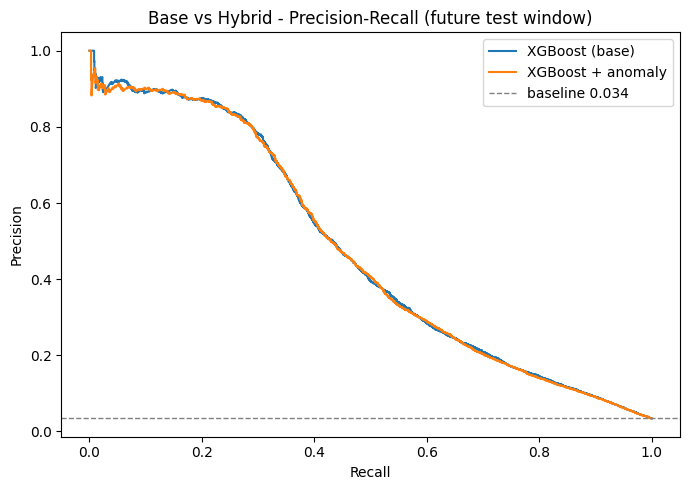

In [6]:
# CELL 6 - Overlayed PR curves (saved for README)
plt.figure(figsize=(7, 5))
for name, s in scores.items():
    p, r, _ = precision_recall_curve(yt, s)
    plt.plot(r, p, label=name)
plt.axhline(base_rate, ls="--", c="gray", lw=1,
            label=f"baseline {base_rate:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Base vs Hybrid - Precision-Recall (future test window)")
plt.legend(); plt.tight_layout()
plt.savefig("../reports/hybrid_vs_base_pr_curve.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [17]:
# CELL 7 - Fraud decision engine, EVALUATED per tier
# Thresholds tuned from notebook 04's cell-9 threshold table.
BLOCK_T, INVESTIGATE_T, ANOMALY_T = 0.90, 0.70, 0.80

hyb  = scores["XGBoost (base)"]
anom = df.loc[test_idx, "anomaly_score"].to_numpy()

decision = np.select(
    [hyb >= BLOCK_T,
     (hyb >= INVESTIGATE_T) | (anom >= ANOMALY_T)],
    ["BLOCK", "INVESTIGATE"],
    default="APPROVE",
)

eval_rows = []
for tier in ["BLOCK", "INVESTIGATE", "APPROVE"]:
    mask = decision == tier
    eval_rows.append({
        "tier": tier,
        "txns": int(mask.sum()),
        "%_traffic": round(mask.mean() * 100, 2),
        "tier_fraud_rate": round(yt[mask].mean(), 3) if mask.any() else np.nan,
        "frauds_caught": int(yt[mask].sum()),
    })
print(pd.DataFrame(eval_rows).set_index("tier"))
print(f"\nFraud captured (BLOCK+INVESTIGATE): "
      f"{yt[decision != 'APPROVE'].sum() / yt.sum():.1%} of all fraud "
      f"on {(decision != 'APPROVE').mean():.1%} of traffic")

               txns  %_traffic  tier_fraud_rate  frauds_caught
tier                                                          
BLOCK          1898       1.61            0.709           1345
INVESTIGATE    3052       2.58            0.212            648
APPROVE      113158      95.81            0.018           2071

Fraud captured (BLOCK+INVESTIGATE): 49.0% of all fraud on 4.2% of traffic


In [18]:
# CELL 8 - Export investigation queue WITH identifiers
results = df.loc[test_idx,
                 ["TransactionDT", "customer_id", "TransactionAmt"]].copy()
results["xgb_score"] = hyb
results["anomaly_score"] = anom
results["decision"] = decision
results["actual_fraud"] = yt
results.to_csv("../data/processed/fraud_predictions.csv", index=False)
print(f"Saved fraud_predictions.csv: {results.shape} (future test window)")

Saved fraud_predictions.csv: (118108, 7) (future test window)


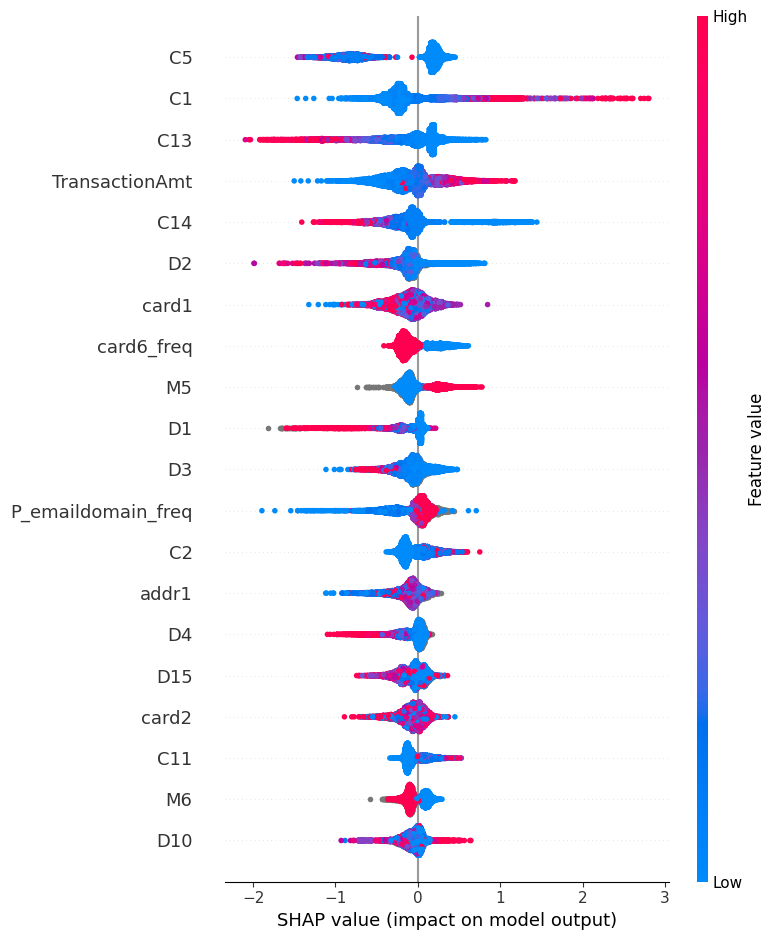

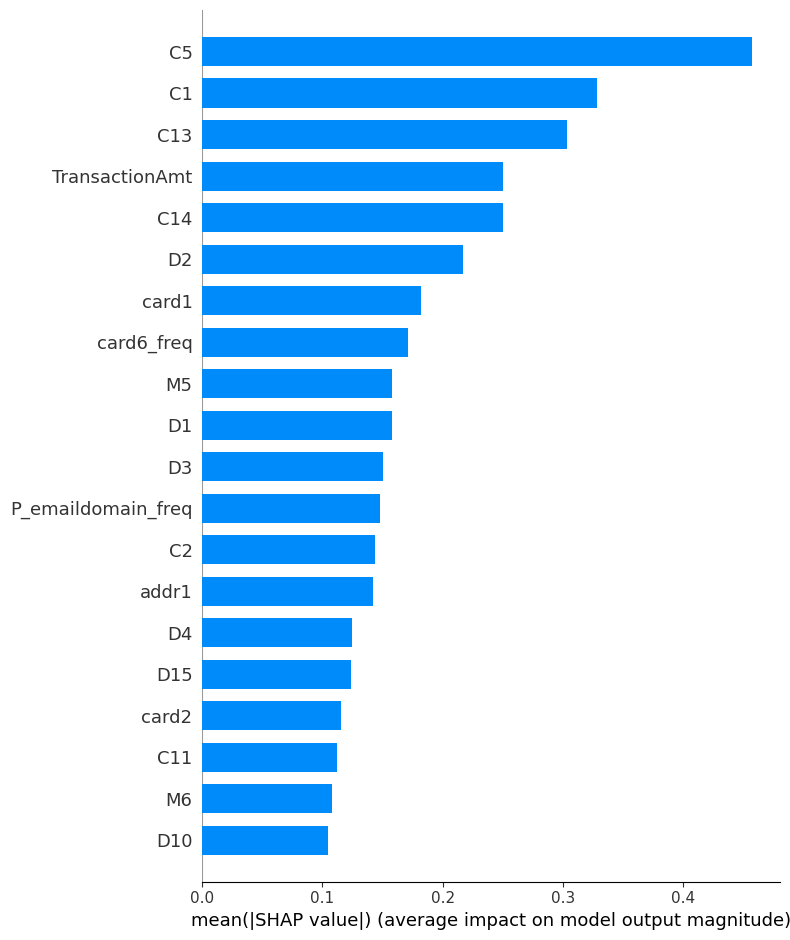

In [19]:
# CELL 9 - SHAP global explanations (sampled, saved as PNGs)
import shap

explainer = shap.TreeExplainer(model_base)          # was: model_hybrid
X_explain = df.loc[test_idx, base_features].sample( # was: hybrid_features
    n=min(10000, len(test_idx)), random_state=42)
shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain, show=False, max_display=20)
plt.tight_layout()
plt.savefig("../reports/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

shap.summary_plot(shap_values, X_explain, plot_type="bar",
                  show=False, max_display=20)
plt.tight_layout()
plt.savefig("../reports/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

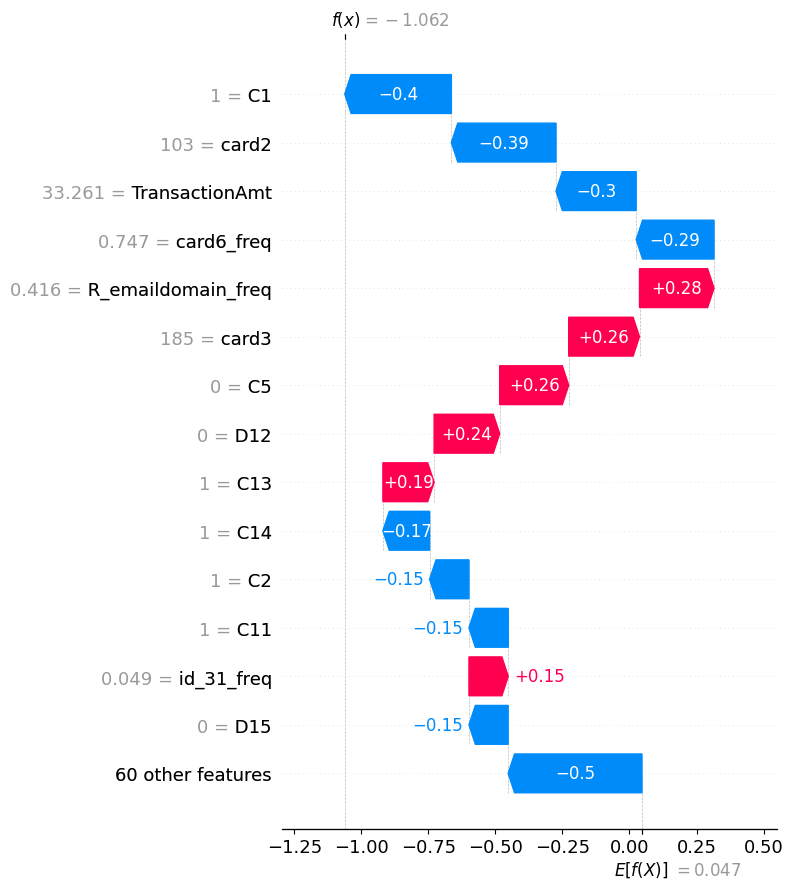

TransactionDT     1970-05-22 02:55:00
TransactionAmt                 33.261
isFraud                             1
Name: 472432, dtype: object


In [20]:
# CELL 10 - Explain one ACTUAL fraud transaction
fraud_positions = np.where(yt == 1)[0]
pos = fraud_positions[0]                      # guaranteed fraud
row = df.loc[test_idx, base_features].iloc[[pos]]
feature_names=base_features

sv = explainer.shap_values(row)[0]
shap.plots.waterfall(
    shap.Explanation(values=sv, base_values=explainer.expected_value,
                     data=row.iloc[0], feature_names=hybrid_features),
    max_display=15, show=False,
)
plt.tight_layout()
plt.savefig("../reports/shap_waterfall_fraud_example.png", dpi=150,
            bbox_inches="tight")
plt.show()
print(df.loc[test_idx].iloc[pos][["TransactionDT", "TransactionAmt", "isFraud"]])

In [21]:
# CELL 11 - Save the PRODUCTION bundle (measured winner) + A/B record
import joblib, json

# The hybrid adds ΔPR-AUC = -0.0018 (within noise) -> ship the simpler
# base model. The anomaly score still serves as the decision-tier backstop
# via the Isolation Forest bundle from notebook 05.
joblib.dump(
    {"model": model_base, "features": base_features,
     "block_threshold": BLOCK_T, "investigate_threshold": INVESTIGATE_T,
     "anomaly_threshold": ANOMALY_T},
    "../models/xgb_production_model.pkl",
)

metrics = {
    "base_model":   comparison.loc["XGBoost (base)"].to_dict(),
    "hybrid_model": comparison.loc["XGBoost + anomaly"].to_dict(),
    "anomaly_delta_pr_auc": float(delta),
    "shipped_model": "base (hybrid delta within noise; simpler model selected)",
    "split": "time-based 70/10/20 (identical to notebooks 04-05)",
    "n_base_features": len(base_features),
    "test_rows": int(len(test_idx)),
}
with open("../models/hybrid_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

{
  "base_model": {
    "ROC-AUC": 0.8938,
    "PR-AUC": 0.472,
    "lift_vs_base": 13.7
  },
  "hybrid_model": {
    "ROC-AUC": 0.8927,
    "PR-AUC": 0.4702,
    "lift_vs_base": 13.7
  },
  "anomaly_delta_pr_auc": -0.0017999999999999683,
  "shipped_model": "base (hybrid delta within noise; simpler model selected)",
  "split": "time-based 70/10/20 (identical to notebooks 04-05)",
  "n_base_features": 74,
  "test_rows": 118108
}
